In [1]:
import os
import json
import torch
import pandas as pd
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

path = Path.cwd().parent / "data/raw/sprint_ai_project1_data"
train_path = path / "train_images"
test_path = path / "test_images"
train_annot_path = path / "train_annotations"

print(f"Train images path: {train_path}")
print(f"Test images path: {test_path}")
print(f"Train annotations path: {train_annot_path}")

Using device: mps
Train images path: /Users/codeit/dev/pill-detection-ai/data/raw/sprint_ai_project1_data/train_images
Test images path: /Users/codeit/dev/pill-detection-ai/data/raw/sprint_ai_project1_data/test_images
Train annotations path: /Users/codeit/dev/pill-detection-ai/data/raw/sprint_ai_project1_data/train_annotations


## 한글 폰트 설정

In [2]:
# OS별 기본 폰트 설정
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Linux':  # Linux (나눔고딕 설치 필요)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

## 파일 수 확인

In [3]:
train_image_files = sorted(train_path.glob('*.png'))
test_image_files = sorted(test_path.glob('*.png'))
train_annotation_files = sorted(train_annot_path.glob('**/*.json'))

# 이미지 장수 확인
print(f"train 이미지 파일 수: {len(train_image_files)}")
print(f"test 이미지 파일 수: {len(test_image_files)}")
print(f"train annotation 파일 수: {len(train_annotation_files)}")

train 이미지 파일 수: 232
test 이미지 파일 수: 842
train annotation 파일 수: 763


## 이미지 사이즈 확인

In [4]:
def get_image_sizes(image_files):
    image_sizes = {}
    for image_file in image_files:
        with Image.open(image_file) as im:
            image_sizes[im.size] = image_sizes.get(im.size, 0) + 1
    return image_sizes

train_image_sizes = get_image_sizes(train_image_files)
print(f"train 이미지 크기: {train_image_sizes}")
test_image_sizes = get_image_sizes(test_image_files)
print(f"test 이미지 크기: {test_image_sizes}")


train 이미지 크기: {(976, 1280): 232}


test 이미지 크기: {(976, 1280): 842}


## annotation을 DataFrame으로 저장 

In [5]:
def build_annotation_df(annot_dir: Path) -> tuple[pd.DataFrame, dict]:
    """annot_dir 아래 모든 json(=알약 1개 annotation)을 행 1개로 하는 DataFrame 생성."""
    cat_id_to_name = {}
    rows = []
    for jp in sorted(annot_dir.rglob("*.json")):
        with open(jp, encoding="utf-8") as f:
            d = json.load(f)
        if not d.get("images") or not d.get("annotations"):
            continue
        img = d["images"][0]
        cat_id_to_name.update({cat["id"]: cat["name"] for cat in d.get("categories", [])})
        for ann in d["annotations"]:
            x, y, w, h = ann["bbox"]
            rows.append({
                "file_name": img["file_name"],
                "category_id": ann["category_id"],
                "category_name": cat_id_to_name.get(ann["category_id"], "unknown"),
                "bbox_x": x,
                "bbox_y": y,
                "bbox_w": w,
                "bbox_h": h,
                "area": ann["area"],
            })
    return pd.DataFrame(rows), cat_id_to_name


ann_df, category_map = build_annotation_df(train_annot_path)
print(f"annotation 행 수: {len(ann_df)}")
print(f"카테고리 맵: {category_map}")
ann_df.head()

annotation 행 수: 763
카테고리 맵: {1900: '보령부스파정 5mg', 16548: '가바토파정 100mg', 19607: '스토가정 10mg', 29451: '레일라정', 33009: '신바로정', 21771: '라비에트정 20mg', 27926: '울트라셋이알서방정', 24850: '놀텍정 10mg', 29345: '비모보정 500/20mg', 16551: '동아가바펜틴정 800mg', 33208: '에스원엠프정 20mg', 2483: '뮤테란캡슐 100mg', 3743: '알드린정', 12778: '다보타민큐정 10mg/병', 13395: '써스펜8시간이알서방정 650mg', 12081: '리렉스펜정 300mg/PTP', 25438: '큐시드정 31.5mg/PTP', 19552: '트루비타정 60mg/병', 22362: '맥시부펜이알정 300mg', 3351: '일양하이트린정 2mg', 3832: '뉴로메드정(옥시라세탐)', 16232: '리피토정 20mg', 16262: '크레스토정 20mg', 16688: '오마코연질캡슐(오메가-3-산에틸에스테르90)', 20238: '플라빅스정 75mg', 21325: '아토르바정 10mg', 22074: '리피로우정 20mg', 29667: '리바로정 4mg', 35206: '아토젯정 10/40mg', 36637: '로수젯정10/5밀리그램', 38162: '로수바미브정 10/20mg', 13900: '에빅사정(메만틴염산염)(비매품)', 18357: '종근당글리아티린연질캡슐(콜린알포세레이트)\xa0', 19232: '콜리네이트연질캡슐 400mg', 20014: '마도파정', 31863: '아질렉트정(라사길린메실산염)', 32310: '글리아타민연질캡슐', 33880: '글리틴정(콜린알포세레이트)', 41768: '카발린캡슐 25mg', 18147: '리리카캡슐 150mg', 3483: '기넥신에프정(은행엽엑스)(수출용)', 20877: '엑스포지정 5/160mg', 30308: '트라젠타듀오정 2.5

,file_name,category_id,category_name,bbox_x,bbox_y,bbox_w,bbox_h,area
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,1900,보령부스파정 5mg,644,845,189,190,35910
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,1900,보령부스파정 5mg,148,241,181,181,32761
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,1900,보령부스파정 5mg,167,248,184,182,33488
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,16548,가바토파정 100mg,144,799,239,239,57121
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,16548,가바토파정 100mg,578,222,233,226,52658


In [128]:
len(ann_df['category_name'].unique())

56

## 이미지당 annotation(bbox) 개수 확인

annotaion 개수 별 이미지 수
count
3    151
4     74
2      7
Name: count, dtype: int64


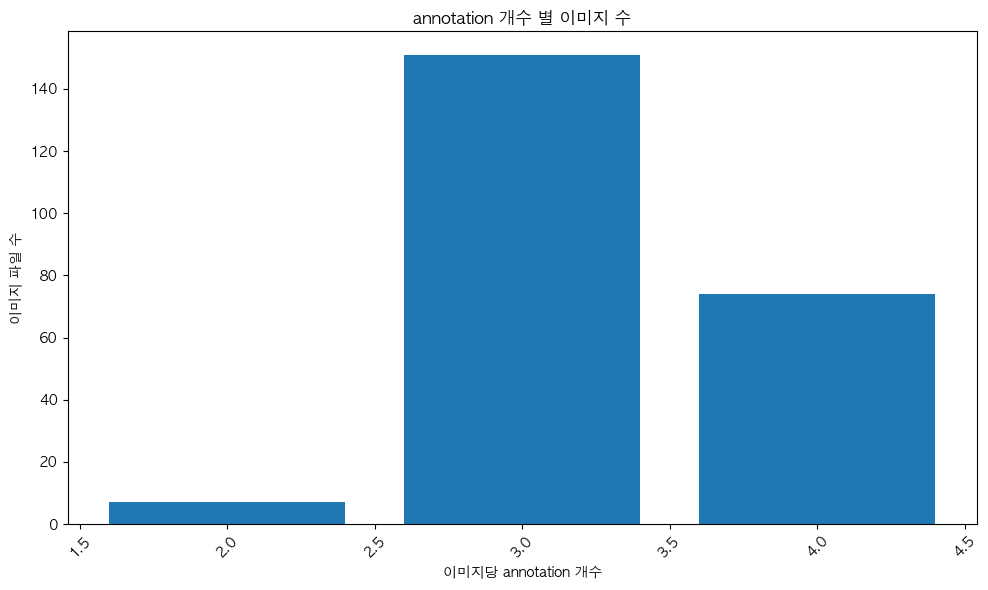

In [6]:
print(f"annotaion 개수 별 이미지 수")
print(ann_df["file_name"].value_counts().value_counts())

plt.figure(figsize=(10, 6))
plt.bar(ann_df["file_name"].value_counts().value_counts().index, ann_df["file_name"].value_counts().value_counts().values)
plt.xlabel("이미지당 annotation 개수")
plt.ylabel("이미지 파일 수")
plt.title("annotation 개수 별 이미지 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## annotation이 없는 이미지가 있는 지 확인

In [7]:
no_annotation_images = []
for img_file in train_image_files:
    if img_file.name not in ann_df["file_name"].values:
        no_annotation_images.append(img_file)

print(f"annotation 없는 이미지 수: {len(no_annotation_images)}")

annotation 없는 이미지 수: 0


## 알약 종류 별 annotation 개수

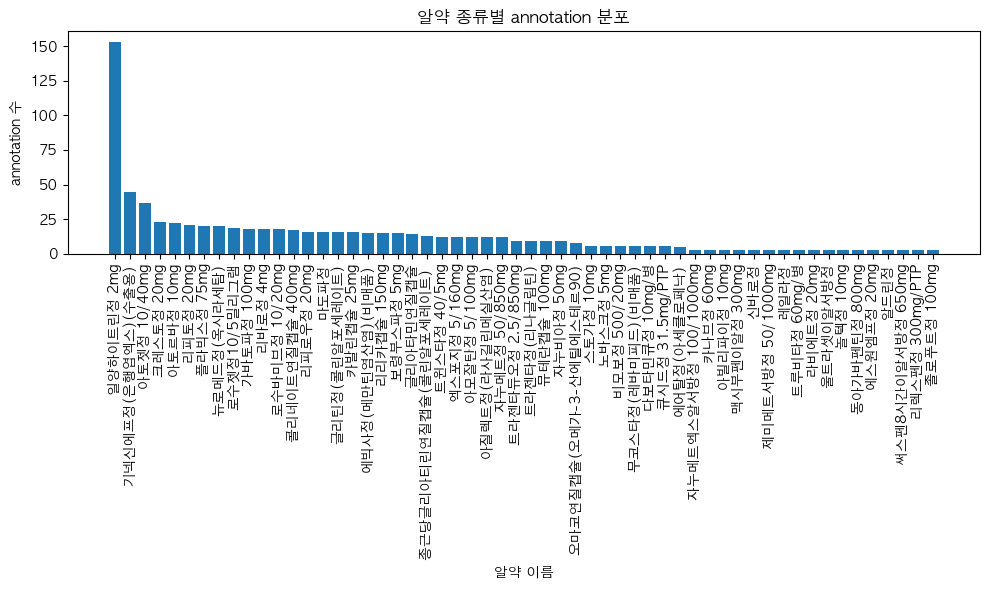

In [8]:
ann_df["category_name"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(ann_df["category_name"].value_counts().index, ann_df["category_name"].value_counts().values)
plt.xlabel("알약 이름")
plt.ylabel("annotation 수")
plt.title("알약 종류별 annotation 분포")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## bbox 크기 분포

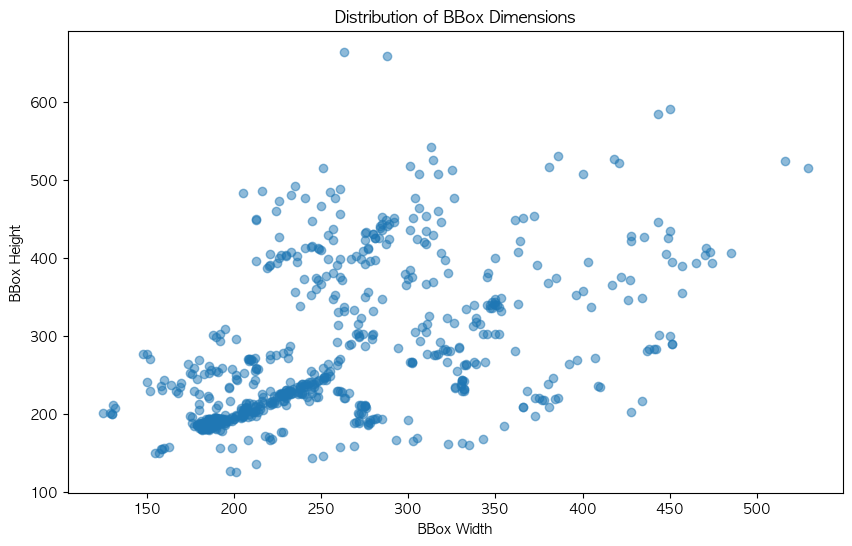

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(ann_df["bbox_w"], ann_df["bbox_h"], 'o', alpha=0.5)
plt.xlabel("BBox Width")
plt.ylabel("BBox Height")
plt.title("Distribution of BBox Dimensions")
plt.show()



## bbox 면적 및 종횡비(aspect ratio) 분포

                area  aspect_ratio  area_ratio
count     763.000000    763.000000  763.000000
mean    70416.916121      0.991525    0.056366
std     42606.147017      0.268859    0.034105
min     23250.000000      0.396084    0.018611
25%     36672.000000      0.828811    0.029355
50%     53600.000000      1.000000    0.042905
75%     93492.500000      1.040713    0.074837
max    272435.000000      2.108374    0.218074


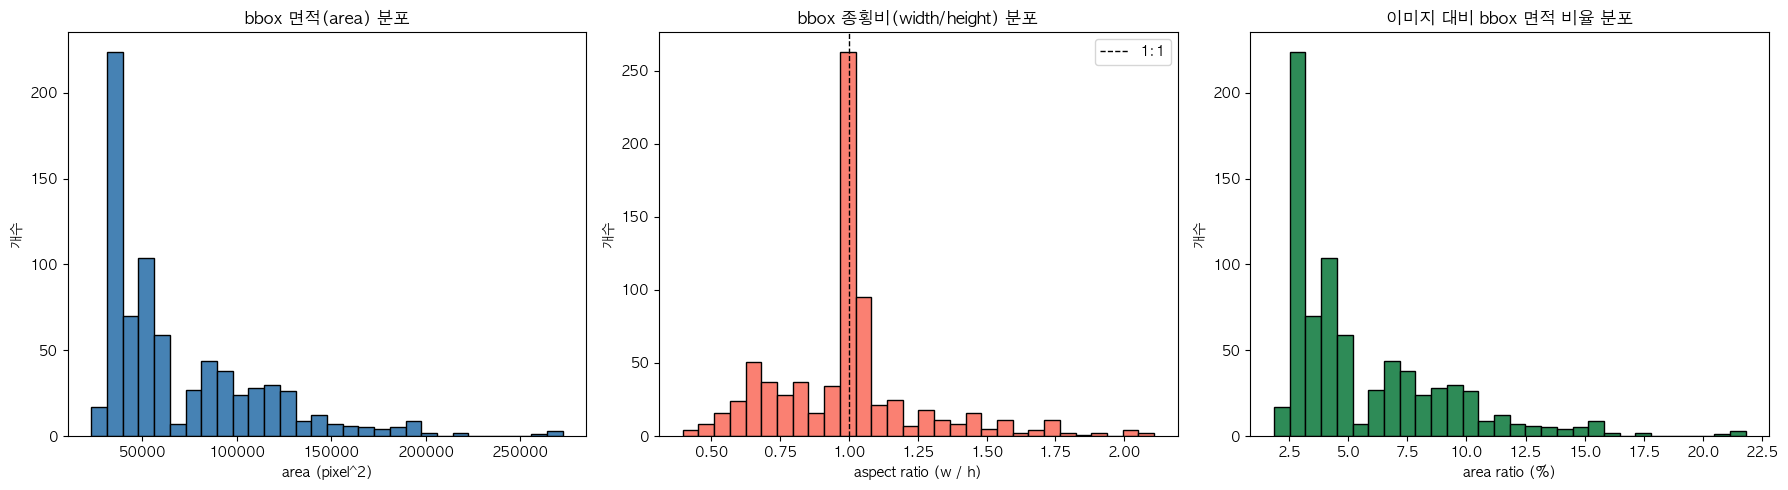

In [10]:
img_w, img_h = next(iter(train_image_sizes))

# 종횡비(가로/세로), 이미지 대비 bbox 면적 비율 계산
ann_df["aspect_ratio"] = ann_df["bbox_w"] / ann_df["bbox_h"]
ann_df["area_ratio"] = ann_df["area"] / (img_w * img_h)

print(ann_df[["area", "aspect_ratio", "area_ratio"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(ann_df["area"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("bbox 면적(area) 분포")
axes[0].set_xlabel("area (pixel^2)")
axes[0].set_ylabel("개수")

axes[1].hist(ann_df["aspect_ratio"], bins=30, color="salmon", edgecolor="black")
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1, label="1:1")
axes[1].set_title("bbox 종횡비(width/height) 분포")
axes[1].set_xlabel("aspect ratio (w / h)")
axes[1].set_ylabel("개수")
axes[1].legend()

axes[2].hist(ann_df["area_ratio"] * 100, bins=30, color="seagreen", edgecolor="black")
axes[2].set_title("이미지 대비 bbox 면적 비율 분포")
axes[2].set_xlabel("area ratio (%)")
axes[2].set_ylabel("개수")

plt.tight_layout()
plt.show()

## bbox가 이미지 경계에서 벗어나는 경우 확인 

In [11]:
# train 이미지는 전부 (976, 1280) 고정 크기
IMG_WIDTH, IMG_HEIGHT = 976, 1280

def find_out_of_bounds(df, img_width, img_height):
    x2 = df["bbox_x"] + df["bbox_w"]
    y2 = df["bbox_y"] + df["bbox_h"]
    mask = (df["bbox_x"] < 0) | (df["bbox_y"] < 0) | (x2 > img_width) | (y2 > img_height)
    return df[mask]

out_of_bounds_df = find_out_of_bounds(ann_df, IMG_WIDTH, IMG_HEIGHT)
print(f"경계를 벗어난 bbox 수: {len(out_of_bounds_df)}")
out_of_bounds_df


경계를 벗어난 bbox 수: 1


,file_name,category_id,category_name,bbox_x,bbox_y,bbox_w,bbox_h,area,aspect_ratio,area_ratio
239,K-003351-016262-018357_0_2_0_2_75_000_200.png,18357,종근당글리아티린연질캡슐(콜린알포세레이트),6567,625,311,315,97965,0.987302,0.078417


## bbox끼리 심하게 겹치는(IoU) 경우 확인

In [12]:
# bbox 간 겹침 정도 IOU를 계산하는 함수
def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1 + w1, x2 + w2)
    inter_y2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


IOU_THRESHOLD = 0.5  # 이 값 이상이면 '심하게 겹침'으로 판단

overlap_records = []
for file_name, group in ann_df.groupby("file_name"):
    boxes = group[["bbox_x", "bbox_y", "bbox_w", "bbox_h", "category_name"]].to_records(index=False)
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            iou = compute_iou(tuple(boxes[i])[:4], tuple(boxes[j])[:4])
            if iou >= IOU_THRESHOLD:
                overlap_records.append({
                    "file_name": file_name,
                    "category_1": boxes[i][4],
                    "category_2": boxes[j][4],
                    "iou": round(iou, 3),
                })

overlap_df = pd.DataFrame(overlap_records).sort_values("iou", ascending=False)
print(f"IoU >= {IOU_THRESHOLD} 로 겹치는 bbox 쌍 수: {len(overlap_df)}")
overlap_df

IoU >= 0.5 로 겹치는 bbox 쌍 수: 3


,file_name,category_1,category_2,iou
0,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,가바토파정 100mg,신바로정,1.0
1,K-003351-020238-031863_0_2_0_2_70_000_200.png,일양하이트린정 2mg,플라빅스정 75mg,1.0
2,K-003351-029667-031863_0_2_0_2_70_000_200.png,일양하이트린정 2mg,아질렉트정(라사길린메실산염),1.0


## 샘플 이미지, 어노테이션 확인해보기

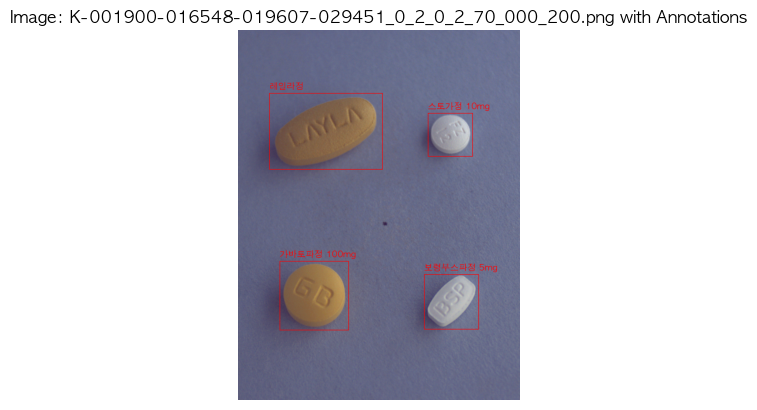

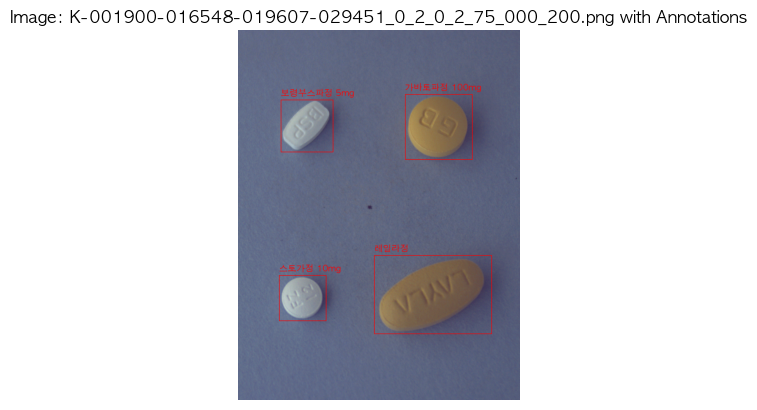

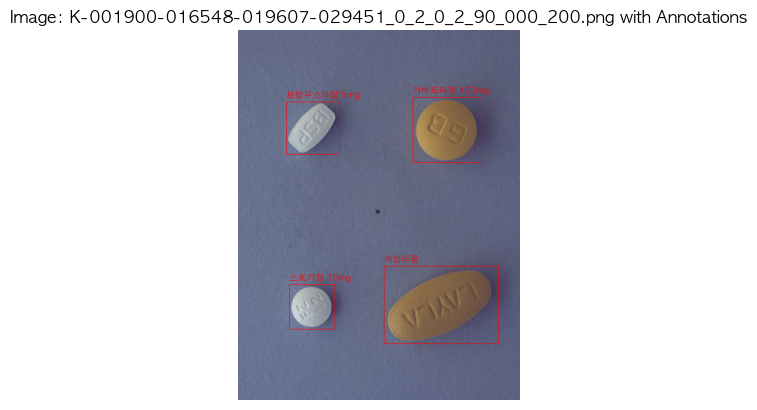

In [13]:
#이미지와 해당 이미지의 annotation을 시각화
def show_image_with_annotaions(image_file):
    image = Image.open(image_file)
    draw = ImageDraw.Draw(image)
    font_path = fm.findfont(fm.FontProperties(family='AppleGothic'))  # macOS용
    font = ImageFont.truetype(font_path, size=30)

    # 해당 이미지의 annotation 가져오기
    image_annotaions = ann_df[ann_df["file_name"] == image_file.name]

    # annotation 그리기
    for annotaion in image_annotaions.itertuples():
        x, y, w, h = annotaion.bbox_x, annotaion.bbox_y, annotaion.bbox_w, annotaion.bbox_h
        category_name = annotaion.category_name
        draw.rectangle([x, y, x + w, y + h], outline="red", width=2)
        draw.text((x, y - 40), category_name, font=font, fill="red")

    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Image: {image_file.name} with Annotations")
    plt.show()

# 3개 실험삼아 시각화
for i in range(3):
    show_image_with_annotaions(train_image_files[i])    

## bbox가 이미지 경계에서 벗어나는 경우 확인 

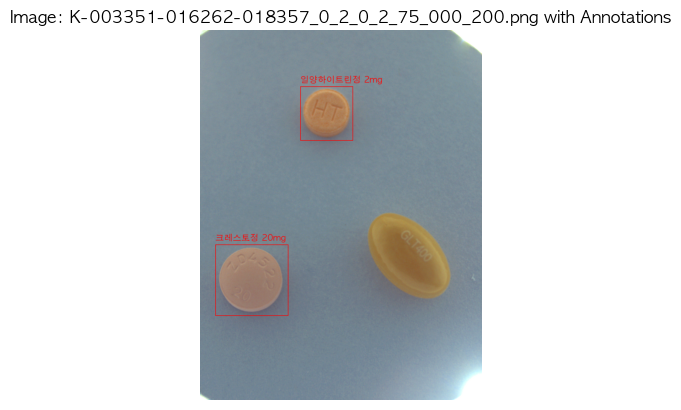

In [14]:
out_of_bounds_images = out_of_bounds_df["file_name"].unique()
for i in out_of_bounds_images:
    show_image_with_annotaions(train_path / i)

## bbox끼리 심하게 겹치는(IoU) 경우 확인

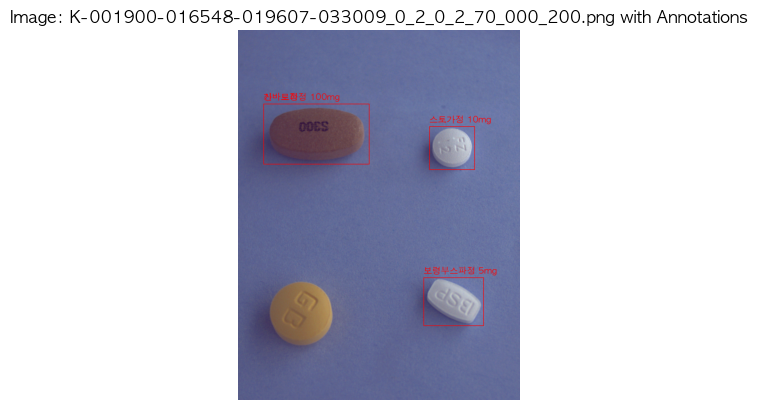

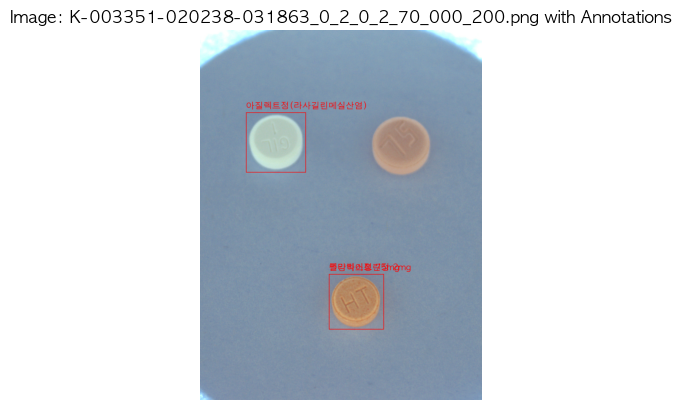

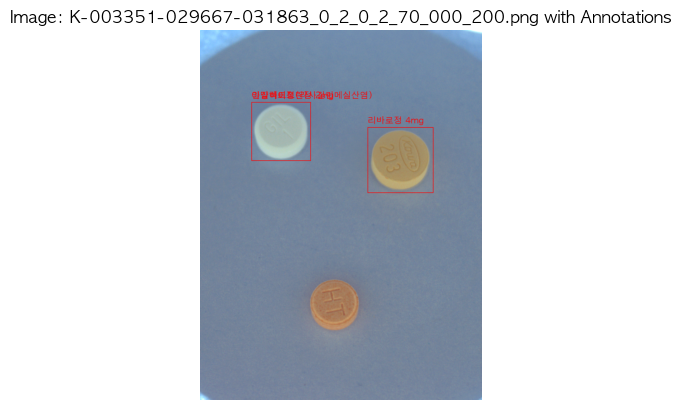

In [15]:
overlap_images = overlap_df["file_name"].unique()
for i in overlap_images:
    show_image_with_annotaions(train_path / i)

## test 이미지 확인

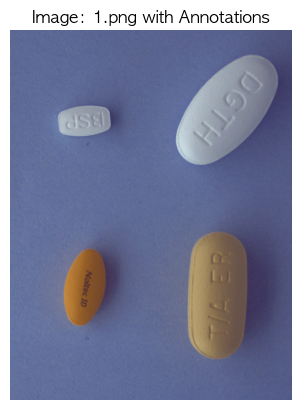

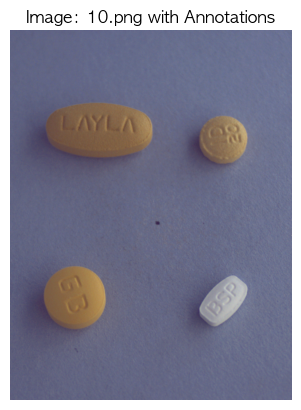

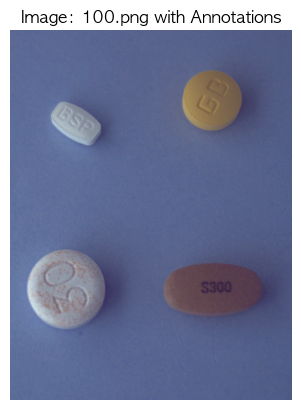

In [16]:
for i in range(3):
    show_image_with_annotaions(test_image_files[i])